# EmosiKu: Klasifikasi Indikasi Gangguan Kesehatan Mental pada Teks Media Sosial Berbahasa Indonesia Menggunakan Model IndoBERT

**Sistem:** Deteksi Depresi dan Kecemasan berbasis NLP (Text Classification)
**Model Utama:** IndoBERT


---


Anggota Kelompok
1. Erlin Sari Ramadhani   (2315061056)
2. Aulia Rahmi Shakira    (2315061104)
3. Nadjwa Tasya Safira    (2315061024)

In [ ]:
!pip install transformers datasets Sastrawi scikit-learn pandas numpy torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 8.6 MB/s eta 0:00:00


## 1. Import Library & Koneksi Google Drive

In [ ]:
import pandas as pd
import numpy as np
import re
import torch
import os
from google.colab import drive
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

drive.mount('/content/drive')

Mounted at /content/drive


## 2. Load Dataset dari Google Drive
Dataset yang digunakan adalah "Depression and Anxiety in Twitter (ID)" oleh Steven Hans.

**Dataset Link:** https://www.kaggle.com/datasets/stevenhans/depression-and-anxiety-in-twitter-id

In [ ]:
path_folder = '/content/drive/MyDrive/EmosiKu/DATASET/'

try:
    train_df = pd.read_csv(os.path.join(path_folder, 'datd_train.csv'))
    test_df = pd.read_csv(os.path.join(path_folder, 'datd_test.csv'))
    print("Dataset berhasil dimuat!")
    display(train_df.head())
except Exception as e:
    print(f"Error memuat dataset: {e}")

Dataset berhasil dimuat!


,text,label
0,"oh pantesan tadi pada rame, ternyata monek mau...",0
1,"Semakin bertambah usia, semakin cemas hidup.",0
2,gelisah bgt astaga,1
3,Udah jangan terlalu cemas sikapku tak berubah ...,0
4,Giliran Aldebaran diambang kematian...Semua ba...,0


## 3. Preprocessing Data
1. Pembersihan teks dari URL, mention (@), hashtag (#), emoji, dan karakter khusus.
2. Normalisasi teks ke lowercase.
3. Stopword removal menggunakan Sastrawi.

In [ ]:
factory_stopword = StopWordRemoverFactory()
stopword = factory_stopword.create_stop_word_remover()

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.lower()
    text = stopword.remove(text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_df['clean_text'] = train_df['text'].apply(clean_text)
test_df['clean_text'] = test_df['text'].apply(clean_text)

display(train_df[['text', 'clean_text', 'label']].head())

,text,clean_text,label
0,"oh pantesan tadi pada rame, ternyata monek mau...",pantesan tadi rame ternyata monek mau cb juni ...,0
1,"Semakin bertambah usia, semakin cemas hidup.",semakin bertambah usia semakin cemas hidup,0
2,gelisah bgt astaga,gelisah bgt astaga,1
3,Udah jangan terlalu cemas sikapku tak berubah ...,udah jangan terlalu cemas sikapku tak berubah ...,0
4,Giliran Aldebaran diambang kematian...Semua ba...,giliran aldebaran diambang kematiansemua baru ...,0


## 4. Tokenisasi dengan IndoBERT
Tokenizer bawaan dari `indobenchmark/indobert-base-p1` untuk mengubah teks menjadi representasi token yang dapat diproses oleh model Transformer.

In [ ]:
model_name = "indobenchmark/indobert-base-p1"
tokenizer = AutoTokenizer.from_pretrained(model_name)

train_encodings = tokenizer(train_df['clean_text'].tolist(), truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(test_df['clean_text'].tolist(), truncation=True, padding=True, max_length=128)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Membuat Dataset PyTorch Custom

In [ ]:
class MentalHealthDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = MentalHealthDataset(train_encodings, train_df['label'].tolist())
test_dataset = MentalHealthDataset(test_encodings, test_df['label'].tolist())

## 5. Fine-Tuning Model IndoBERT
Model pre-trained `IndoBERT-base` di-fine-tune dengan menambahkan Dense Layer + Softmax di akhir arsitektur untuk klasifikasi dua kelas:
- 0: Normal
- 1: Indikasi Gangguan Mental

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall}

training_args = TrainingArguments(
    output_dir='./EmosiKu_Model',
    num_train_epochs=8,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


## 6. Training & Evaluasi Model

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.577957,0.405610,0.830909,0.661818,0.798246,0.565217
2,0.484187,0.372092,0.834545,0.734694,0.692308,0.782609
3,0.386736,0.374465,0.840000,0.712418,0.751724,0.677019
4,0.243327,0.475635,0.820000,0.711370,0.670330,0.757764
5,0.207805,0.655259,0.825455,0.714286,0.685714,0.745342
6,0.119340,0.675957,0.836364,0.741379,0.689840,0.801242
7,0.096679,0.738029,0.841818,0.710963,0.764286,0.664596
8,0.065454,0.783871,0.843636,0.729560,0.738854,0.720497


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=1104, training_loss=0.2695252452167156, metrics={'train_runtime': 363.5633, 'train_samples_per_second': 48.432, 'train_steps_per_second': 3.037, 'total_flos': 660544415591520.0, 'train_loss': 0.2695252452167156, 'epoch': 8.0})

In [ ]:
eval_results = trainer.evaluate()
print(f"Hasil Evaluasi: {eval_results}")

Hasil Evaluasi: {'eval_loss': 0.6754161715507507, 'eval_accuracy': 0.8363636363636363, 'eval_f1': 0.7413793103448276, 'eval_precision': 0.6898395721925134, 'eval_recall': 0.8012422360248447, 'eval_runtime': 1.9842, 'eval_samples_per_second': 277.188, 'eval_steps_per_second': 4.536, 'epoch': 8.0}


In [ ]:
model_save_path = '/content/drive/MyDrive/EmosiKu_Model/best_model'
os.makedirs(model_save_path, exist_ok=True)
trainer.save_model(model_save_path)
tokenizer.save_pretrained(model_save_path)
print(f"Model berhasil disimpan secara permanen di {model_save_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model berhasil disimpan secara permanen di /content/drive/MyDrive/EmosiKu_Model/best_model


##7. Grafik Loss Train

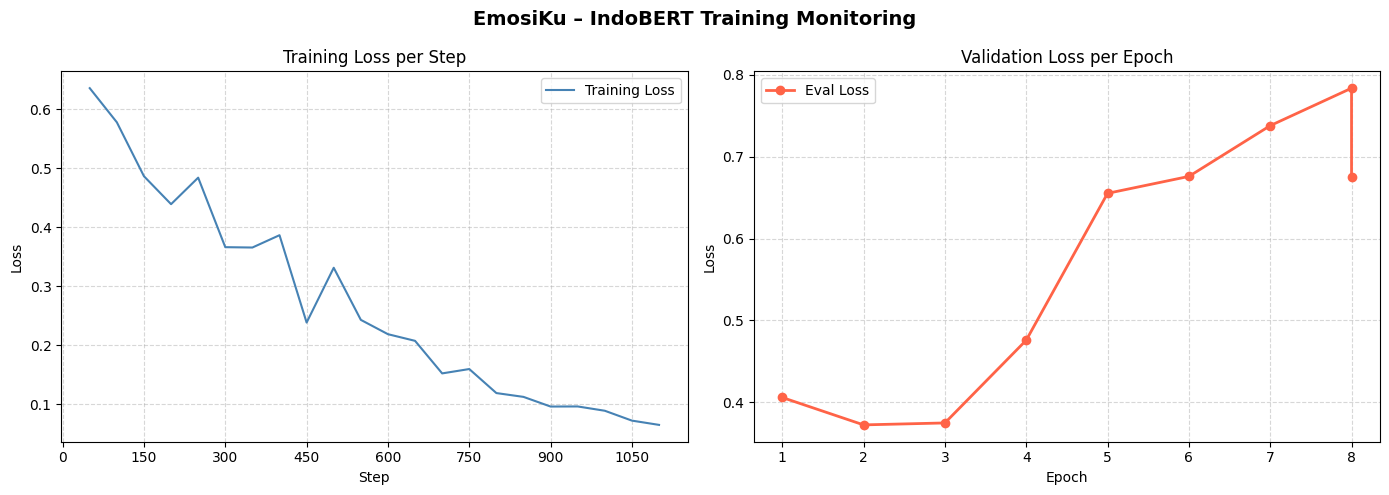

Grafik disimpan ke Google Drive.


In [ ]:

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

log_history = trainer.state.log_history

train_logs = [x for x in log_history if 'loss' in x and 'eval_loss' not in x]
eval_logs  = [x for x in log_history if 'eval_loss' in x]

train_steps  = [x['step']  for x in train_logs]
train_losses = [x['loss']  for x in train_logs]

eval_epochs  = [x['epoch']     for x in eval_logs]
eval_losses  = [x['eval_loss'] for x in eval_logs]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('EmosiKu – IndoBERT Training Monitoring', fontsize=14, fontweight='bold')

axes[0].plot(train_steps, train_losses, color='steelblue', linewidth=1.5, label='Training Loss')
axes[0].set_title('Training Loss per Step')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

axes[1].plot(eval_epochs, eval_losses, color='tomato', marker='o', linewidth=2, label='Eval Loss')
axes[1].set_title('Validation Loss per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/EmosiKu_Model/training_loss_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik disimpan ke Google Drive.")

##8. Confusion matrix

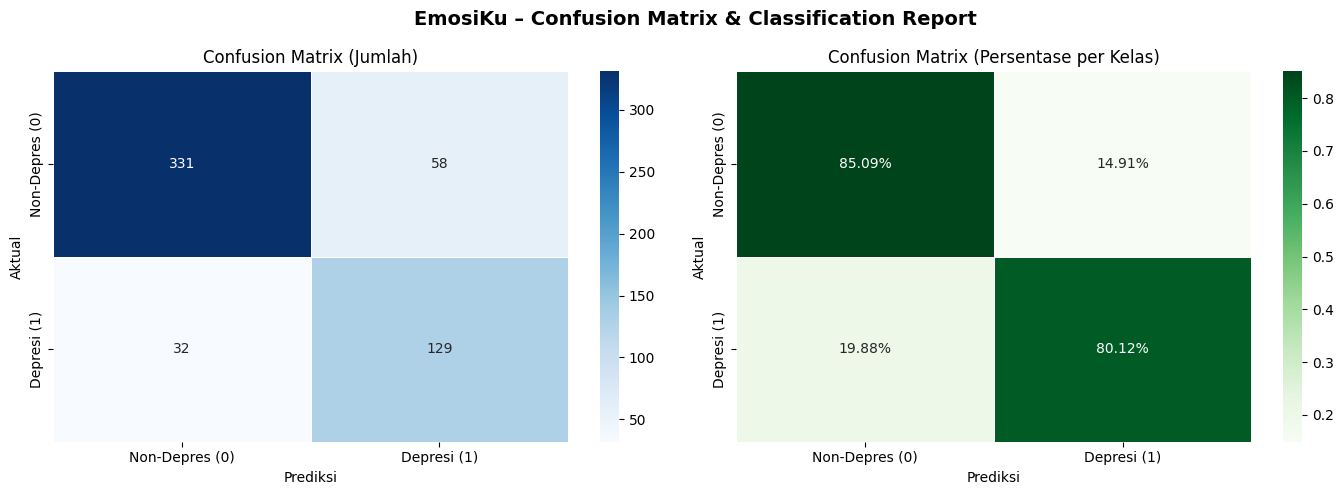


  CLASSIFICATION REPORT
                precision    recall  f1-score   support

Non-Depres (0)       0.91      0.85      0.88       389
   Depresi (1)       0.69      0.80      0.74       161

      accuracy                           0.84       550
     macro avg       0.80      0.83      0.81       550
  weighted avg       0.85      0.84      0.84       550

True Negative  (TN): 331  → Non-depresi diprediksi benar
False Positive (FP): 58  → Non-depresi salah diprediksi depresi
False Negative (FN): 32  → Depresi salah diprediksi non-depresi
True Positive  (TP): 129  → Depresi diprediksi benar

Grafik disimpan ke Google Drive.


In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

predictions_output = trainer.predict(test_dataset)
y_pred = np.argmax(predictions_output.predictions, axis=1)
y_true = predictions_output.label_ids

class_names = ['Non-Depres (0)', 'Depresi (1)']

cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('EmosiKu – Confusion Matrix & Classification Report', fontsize=14, fontweight='bold')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Confusion Matrix (Jumlah)')
axes[0].set_xlabel('Prediksi')
axes[0].set_ylabel('Aktual')

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, ax=axes[1])
axes[1].set_title('Confusion Matrix (Persentase per Kelas)')
axes[1].set_xlabel('Prediksi')
axes[1].set_ylabel('Aktual')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/EmosiKu_Model/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*55)
print("  CLASSIFICATION REPORT")
print("="*55)
print(classification_report(y_true, y_pred, target_names=class_names))

tn, fp, fn, tp = cm.ravel()
print(f"True Negative  (TN): {tn}  → Non-depresi diprediksi benar")
print(f"False Positive (FP): {fp}  → Non-depresi salah diprediksi depresi")
print(f"False Negative (FN): {fn}  → Depresi salah diprediksi non-depresi")
print(f"True Positive  (TP): {tp}  → Depresi diprediksi benar")
print("\nGrafik disimpan ke Google Drive.")

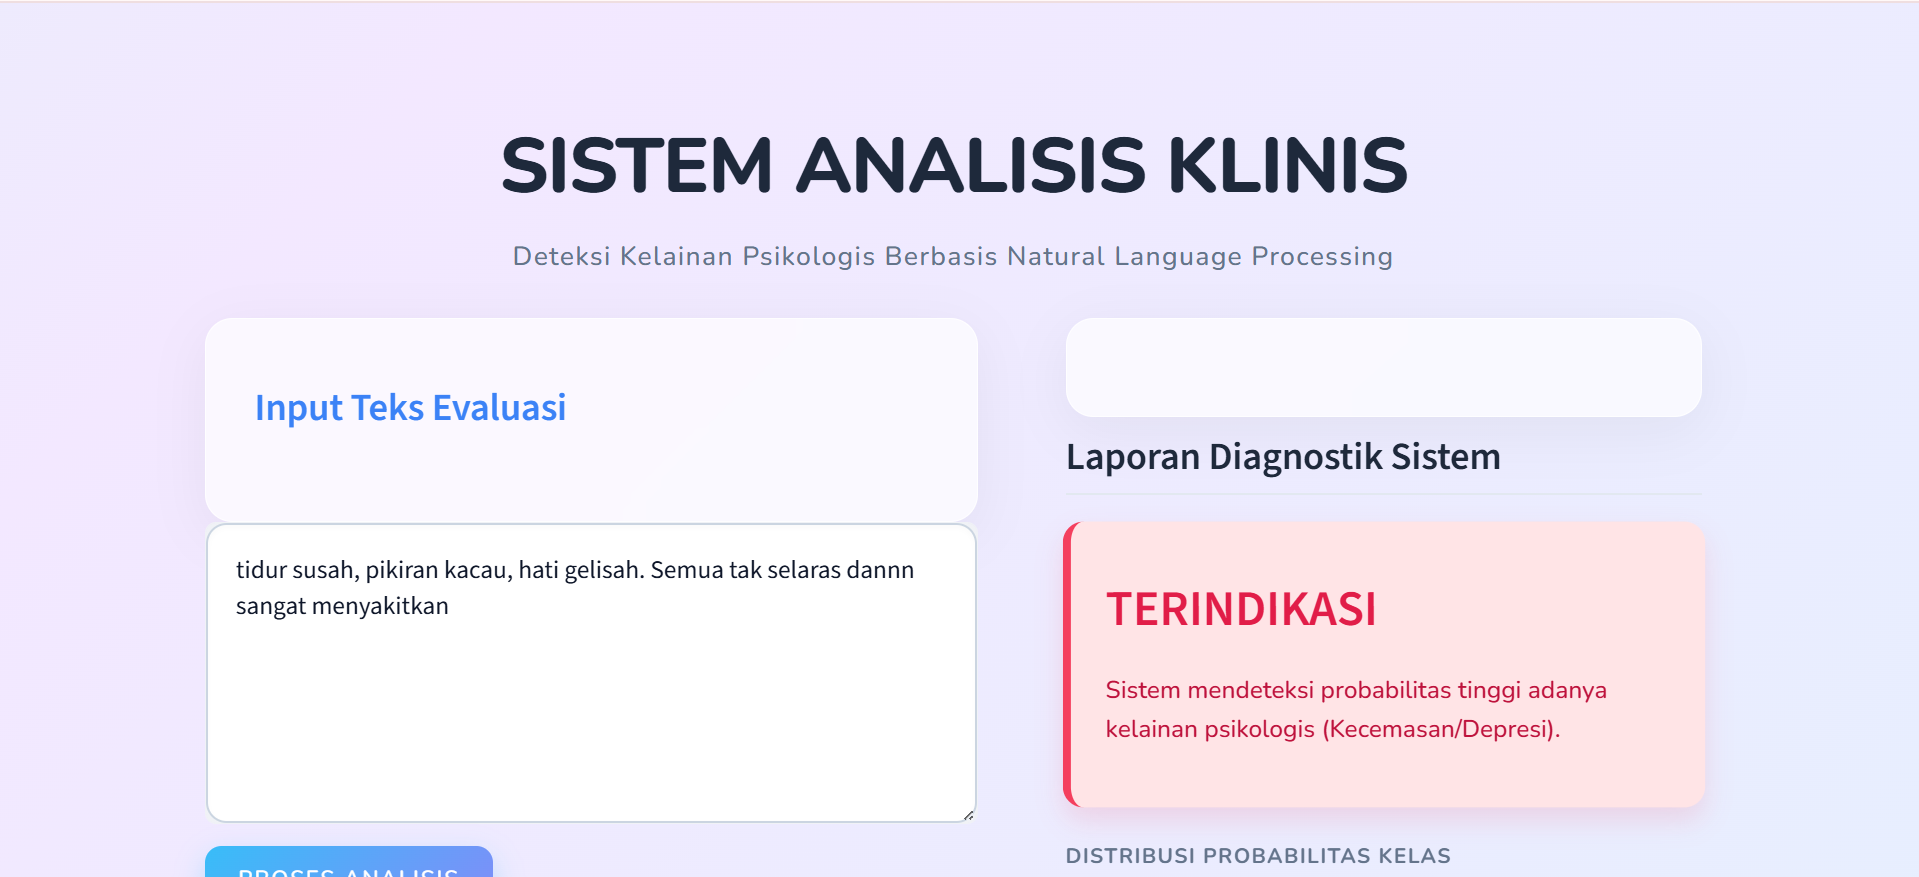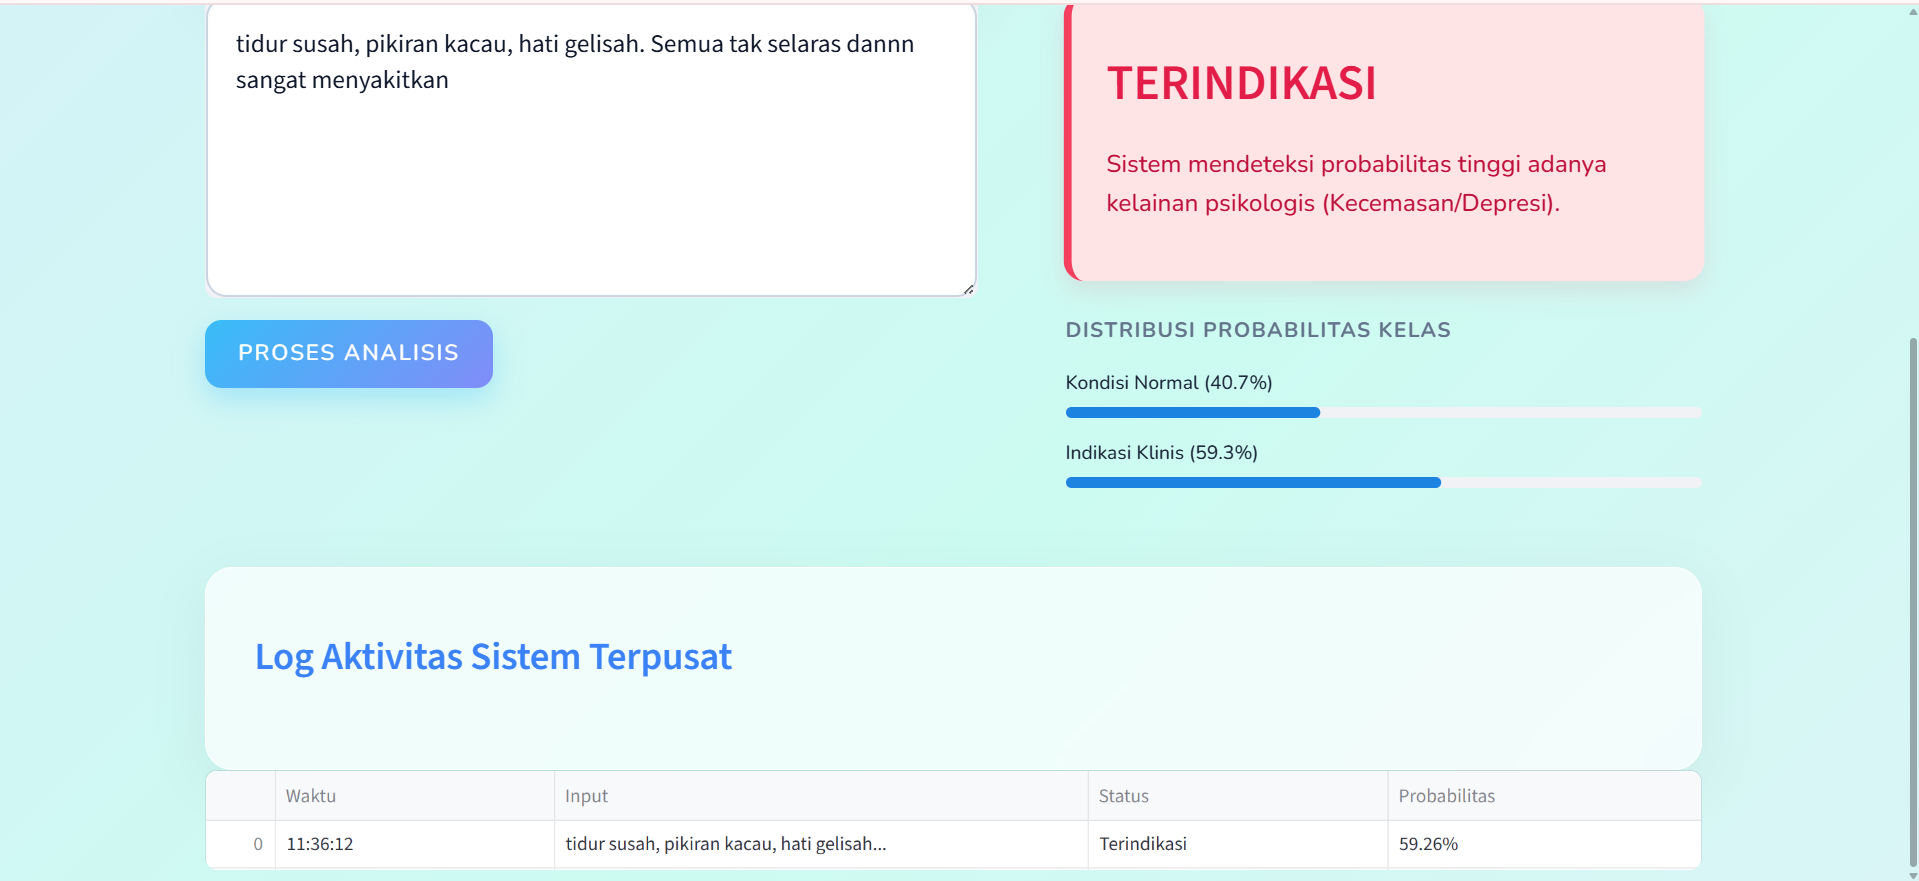